In [16]:
import sys
import os
import math
import torch
import platform
import copy
# import glob
import time
# from torchsummary import summary
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
sys.path.append('..')

# Project modules
from src.utility.config import (
    DEVICE, 
    # CSV_DIR,
    BASELINE_MODEL_PATH, 
    QUANTIZED_MODELS,
    MODELS_DIR 
)
from src.utility.quantizer import Quantization
from src.utility.utils import get_data_loaders
from src.model import CNN
from src.layers import QuantizedLayerMixin

CONFIG = {
    "baseline_path": BASELINE_MODEL_PATH,
    "quant_model_name": "Aff_INT8", # Nur hier ändern!
    "batch_size": 32,
    "vis_samples": 50
}

sns.set_theme(style="whitegrid")

In [2]:
def check_system_capabilities():
    print(f"--- System Info ---")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"Python Version: {sys.version.split()[0]}")
    # FIX: Nutzung von platform statt torch.version.os
    print(f"OS: {platform.system()} ({platform.release()})")
    print(f"CUDA Available: {torch.cuda.is_available()}")
    
    print(f"\n--- 1. Compiler Backends (for torchao/torch.compile) ---")
    backends = torch.compiler.list_backends()
    print(f"Available Backends: {backends}")
    
    if 'inductor' in backends:
        print("-> 'inductor' is listed (Required for high-perf torchao).")
        # Check for Triton (the engine behind inductor)
        try:
            import triton
            print(f"-> SUCCESS: Triton is installed! Version: {triton.__version__}")
        except ImportError:
            print("-> WARNING: 'inductor' is listed, but 'triton' is NOT installed.")
            print("   If you are on Linux, try 'pip install triton'.")

    print(f"\n--- 2. Low-Level Quantization Engines ---")
    print(f"Supported Engines: {torch.backends.quantized.supported_engines}")
    print(f"Current Default Engine: {torch.backends.quantized.engine}")

    print(f"\n--- 3. MKLDNN / OneDNN Support (x86 Acceleration) ---")
    print(f"MKLDNN Available: {torch.backends.mkldnn.is_available()}")

In [3]:
def check_fx_quantization_type(model):
    """
    Spezielle Prüf-Funktion für FX Graph Mode Modelle.
    Sucht nach 'PackedParams', entpackt sie und prüft das Quantisierungs-Schema.
    """
    print("--- FX Quantisierungs-Check ---")
    found = False
    
    # Wir iterieren durch alle Attribute des Modells
    # FX speichert Gewichte oft als Attribute wie 'conv1_packed_weight_0'
    for name in dir(model):
        attr = getattr(model, name)
        
        # Prüfung: Ist es ein gepacktes Gewichtspaket?
        # Diese Objekte haben meist eine .unpack() Methode
        if hasattr(attr, 'unpack') and "packed_weight" in name:
            print(f"Untersuche Parameter-Paket: '{name}'")
            
            # Entpacken (gibt meist Weight, Bias zurück)
            try:
                weight, bias = attr.unpack()
                
                # Jetzt haben wir den echten quantisierten Tensor
                scheme = weight.qscheme()
                print(f"  QScheme: {scheme}")
                
                # Check auf Zero Point (der mathematische Beweis)
                if scheme in [torch.per_channel_symmetric, torch.per_tensor_symmetric]:
                    # Bei Symmetric muss ZP überall 0 sein
                    zps = weight.q_zero_point()
                    # Wenn zps ein Tensor ist, prüfen wir alle Werte
                    if torch.all(zps == 0):
                        print("  -> BESTÄTIGT: Symmetrisch (Alle Zero-Points sind 0).")
                    else:
                        print("  -> WARNUNG: Schema ist symmetrisch, aber Zero-Points sind ungleich 0!")
                        
                elif scheme in [torch.per_channel_affine, torch.per_tensor_affine]:
                    print("  -> BESTÄTIGT: Affine (Asymmetrisch).")
                
                found = True
                break # Ein Treffer reicht uns
            except Exception as e:
                print(f"  Konnte Paket nicht entpacken: {e}")

    if not found:
        print("Keine gepackten Gewichte gefunden. (Vielleicht ist das Modell noch Float?)")

In [4]:
def _fix_quantization_dtypes(module, method='affine', bits=8):
    """
    Interne Hilfsfunktion: Setzt Flags und repariert Float->Int Casts für einen Layer.
    """
    module.quant_method = method
    module.num_bits = bits
    module.quant_mode = True
    
    if hasattr(module, 'act_scale') and module.act_scale.item() != 1.0:
        module.activation_calibrated = True
        
    if method == 'affine':
        target_dtype = torch.uint8
    else: # symmetric / power2
        target_dtype = torch.int8
        
    if hasattr(module, 'weight') and module.weight.dtype == torch.float32:
        module.weight = nn.Parameter(module.weight.data.to(target_dtype), requires_grad=False)

def load_model(model_class, num_classes, model_path, quant_config=None):
    """
    Universal-Loader für Baseline UND Quantisierte Modelle.
    """
    model = model_class(num_classes=num_classes).to(DEVICE)
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Modell nicht gefunden: {model_path}")
        
    state_dict = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(state_dict)
    
    if quant_config:
        print(f"Repariere Quantisierung ({quant_config})...")
        method = quant_config.get('method', 'affine')
        bits = quant_config.get('bits', 8)

        for name, module in model.named_modules():
            # Wir prüfen duck-typing oder Klasse
            if hasattr(module, "quant_mode") or isinstance(module, QuantizedLayerMixin):
             _fix_quantization_dtypes(module, method, bits)
    else:
        print(" Baseline Modus (Float32).")
        if hasattr(model, 'convert_to_baseline'):
            model.convert_to_baseline()
            
    model.eval()
    return model

In [5]:
def get_all_predictions(model, data_loader, device='cpu'):
    """
    Kompilier-sichere Version von get_all_predictions.
    Verhindert model.to(device) Aufrufe für kompilierte Modelle.
    """
    # 1. Prüfen, ob Modell kompiliert ist
    is_compiled = isinstance(model, torch._dynamo.eval_frame.OptimizedModule)
    
    # Nur verschieben, wenn NICHT kompiliert
    if not is_compiled:
        model.to(device)
        
    model.eval()
    
    all_preds = []
    all_targets = []
    sample_images = [] # Zum Speichern für Visualisierung
    
    with torch.no_grad():
        for i, (data, target) in enumerate(data_loader):
            # Daten müssen wir IMMER verschieben
            data = data.to(device)
            
            output = model(data)
            pred = output.argmax(dim=1).cpu().numpy()
            
            all_preds.extend(pred)
            all_targets.extend(target.numpy())
            
            # Ein paar Beispielbilder speichern (vom ersten Batch)
            if i == 0:
                sample_images = data.cpu()

    return {
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
        "sample_images": sample_images
    }

def print_metrics(results_dict, model_name="Model"):
    # TODO: Berechne Accuracy, Precision, Recall basierend auf results_dict['preds'] und ['targets']
    # Nutze sklearn classification_report
    acc = accuracy_score(results_dict['targets'], results_dict['preds'])
    error_rate = 1.0 - acc

    print(f"\n--- Performance: {model_name} ---")
    print(f"Accuracy:   {acc:.4f} ({acc*100:.2f}%)")
    print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")
    print("-" * 40)

    print(classification_report(results_dict['targets'], results_dict['preds'], digits=4))

In [6]:
def measure_inference_time(model, data_loader, device='cpu'):
    # FIX: Prüfen, ob es ein kompiliertes Modell ist
    is_compiled = isinstance(model, torch._dynamo.eval_frame.OptimizedModule)
    
    # Nur verschieben, wenn es NICHT kompiliert ist
    if not is_compiled:
        model.to(device)
        
    model.eval()
    
    # Warm-up (kurz)
    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            if i >= 5: break
            data = data.to(device)
            model(data)
            
    # Echte Messung
    start_time = time.time()
    count = 0
    
    with torch.no_grad():
        for i, (data, _) in enumerate(data_loader):
            # Wir messen hier z.B. 100 Batches, damit es nicht ewig dauert
            if i >= 100: break
            
            data = data.to(device)
            model(data)
            count += data.size(0)
            
    end_time = time.time()
    
    total_time = end_time - start_time
    fps = count / total_time
    latency_ms = (total_time / count) * 1000
    
    return fps, latency_ms

In [7]:
def plot_confusion_matrix(targets, preds, class_names, title="Confusion Matrix"):
    """Plottet eine saubere Confusion Matrix der Top-Klassen"""
    # Wir nehmen nur die häufigsten Klassen, damit der Plot lesbar bleibt
    from collections import Counter
    TOP_N = 15
    
    counts = Counter(targets)
    top_classes_idx = [c for c, _ in counts.most_common(TOP_N)]
    
    # Filtern
    mask = np.isin(targets, top_classes_idx) & np.isin(preds, top_classes_idx)
    filt_targets = targets[mask]
    filt_preds = preds[mask]
    
    cm = confusion_matrix(filt_targets, filt_preds, labels=top_classes_idx)
    
    # Namen mappen
    if class_names:
        labels = [class_names[i] for i in top_classes_idx]
    else:
        labels = top_classes_idx

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels)
    plt.title(f"{title} (Top {TOP_N} Classes)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_visual_comparison(images, preds_base, preds_quant, targets, class_names, num_samples=32):
    """
    Zeigt Bilder im Raster an.
    Farben: Grün (beide korrekt), Rot (beide falsch), Orange (Quantisierung weicht ab).
    """
    # Wir nutzen nur so viele Bilder, wie wir haben
    n = min(len(images), num_samples, len(preds_base))
    
    cols = 8
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3.0 * rows))
    axes = axes.flatten()
    
    print(f"Visualisiere {n} Beispiele...")
    
    for i in range(n):
        ax = axes[i]
        
        # Bild normalisieren für Anzeige (angenommen -1..1 Range)
        img = images[i].permute(1, 2, 0).numpy()
        img = (img * 0.5) + 0.5 
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        p_base = preds_base[i]
        p_quant = preds_quant[i]
        true_lbl = targets[i]
        
        # Logik für Titel-Farbe
        is_diff = (p_base != p_quant)
        is_correct = (p_quant == true_lbl)
        
        if is_diff:
            color = 'orange'
            box_text = "DIFF"
        elif is_correct:
            color = 'green'
            box_text = "OK"
        else:
            color = 'red'
            box_text = "ERR"
            
        # Klassen-Namen holen
        name_q = class_names[p_quant] if class_names else str(p_quant)
        # name_t = class_names[true_lbl] if class_names else str(true_lbl)
        
        title = f"Q: {name_q}\n[{box_text}]"
        ax.set_title(title, color=color, fontweight='bold', fontsize=9)
        ax.axis('off')
        
    # Restliche Achsen ausschalten
    for j in range(n, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

def plot_weight_distribution(model, layer_type=nn.Conv2d):
    """Zeigt die Gewichtsverteilung als Boxplot"""
    data = []
    labels = []
    
    for name, module in model.named_modules():
        if isinstance(module, layer_type):
            w = module.weight.detach().cpu().numpy().flatten()
            data.append(w)
            labels.append(name)
            
    if not data:
        print("Keine Layer für Weight-Plot gefunden.")
        return

    plt.figure(figsize=(12, 6))
    plt.boxplot(data, tick_labels=labels, showfliers=False)
    plt.xticks(rotation=90)
    plt.title(f"Gewichtsverteilung ({layer_type.__name__})")
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
train_loader, test_loader, num_classes = get_data_loaders()
dummy_input = next(iter(train_loader))[0].to('cpu')
# Versuche Klassennamen zu finden

class_names = getattr(test_loader.dataset, 'classes', None)
if not class_names and hasattr(test_loader.dataset, 'dataset'):
    class_names = getattr(test_loader.dataset.dataset, 'classes', None)

baseline_model = load_model(CNN, num_classes, CONFIG['baseline_path'])

print("Evaluiere Accuracy...")

# Baseline

fps_base, lat_base = measure_inference_time(baseline_model, test_loader, device='cpu')
print(f"Baseline:  {fps_base:.2f} Bilder/sek | Latenz: {lat_base:.2f} ms")
res_base = get_all_predictions(baseline_model, test_loader, device='cpu')
print_metrics(res_base, "Baseline Model")



 Baseline Modus (Float32).
Evaluiere Accuracy...
Baseline:  175.04 Bilder/sek | Latenz: 5.71 ms

--- Performance: Baseline Model ---
Accuracy:   0.9091 (90.91%)
Error Rate: 0.0909 (9.09%)
----------------------------------------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6250    1.0000    0.7692         5
           3     1.0000    1.0000    1.0000         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.6667    0.8000        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     0.5000    1.0000    0.6667         3
          10     0.8571    1.0000    0.9231         6
          11     1.0000    1.0000    1.0000         4
          12     0.0000    0.0000    0.0000         1
          13  

/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [ ]:
#Int8 Weight and Activations of Linear Layers

print("\n=== Experiment 2: TorchAO Int8 Weight and Activations ===")

model_for_ao = copy.deepcopy(baseline_model)
ao_int8 = Quantization.apply_torchao_quantization(model_for_ao, method="dynamic")

print("Wärme auf (Weight und Activations Kompilierung)...")
with torch.no_grad():
    for _ in range(5): ao_int8(dummy_input)
print("Fertig.")

fps_int8, lat_int8 = measure_inference_time(ao_int8, test_loader, device='cpu')
print(f"Int8:  {fps_int8:.2f} Bilder/sek | Latenz: {lat_int8:.2f} ms")
res_int8 = get_all_predictions(ao_int8, test_loader, device='cpu')
print_metrics(res_int8, "TorchAO Int8")

speedup8 = fps_int8 / fps_base
print(f"\n-> Beschleunigung: {speedup8:.2f}x schneller als Base")


=== Experiment 2: TorchAO Int8 Weight and Activations ===
--- TorchAO: Wende 'dynamic' Quantisierung an ---
Kompiliere mit torch.compile (Backend='inductor')...


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torchao/utils.py:390: UserWarning: `int8_dynamic_activation_int8_weight` is deprecated and will be removed in a future release. Please use `Int8DynamicActivationInt8WeightConfig` instead. Example usage:
    quantize_(model, Int8DynamicActivationInt8WeightConfig(...))
  warnings.warn(


Wärme auf (Weight und Activations Kompilierung)...
Fertig.

--- Performance: TorchAO Int8 ---
Accuracy:   0.9091 (90.91%)
Error Rate: 0.0909 (9.09%)
----------------------------------------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6250    1.0000    0.7692         5
           3     1.0000    1.0000    1.0000         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.6667    0.8000        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     0.5000    1.0000    0.6667         3
          10     0.8571    1.0000    0.9231         6
          11     1.0000    1.0000    1.0000         4
          12     0.0000    0.0000    0.0000         1
          13     1.0000    0.9167    0.9565        12

/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [ ]:
# Int8 Weight Only of linear layers

print("\n=== Experiment 2: TorchAO Int8 Weight Only ===")

model_for_weight_only = copy.deepcopy(baseline_model)
ao_weight = Quantization.apply_torchao_quantization(model_for_weight_only, method="weight_only")

print("Wärme auf (IntWeight Only Kompilierung)...")
with torch.no_grad():
    for _ in range(5): ao_weight(dummy_input)

fps_weight, lat_weight = measure_inference_time(ao_weight, test_loader, device='cpu')
print(f"Baseline:  {fps_weight:.2f} Bilder/sek | Latenz: {lat_weight:.2f} ms")
res_weight = get_all_predictions(ao_weight, test_loader, device='cpu')
print_metrics(res_weight, "TorchAO Weight only")

speedup_weight_only = fps_weight / fps_base
print(f"\n-> Beschleunigung: {speedup_weight_only:.2f}x schneller als Base")


=== Experiment 2: TorchAO Int8 Weight Only ===
 Baseline Modus (Float32).
--- TorchAO: Wende 'weight_only' Quantisierung an ---
Kompiliere mit torch.compile (Backend='inductor')...
Wärme auf (IntWeight Only Kompilierung)...


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torchao/utils.py:390: UserWarning: `int8_weight_only` is deprecated and will be removed in a future release. Please use `Int8WeightOnlyConfig` instead. Example usage:
    quantize_(model, Int8WeightOnlyConfig(...))
  warnings.warn(
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torchao/quantization/quant_api.py:1356: UserWarning: Config Deprecation: version 1 of Int8WeightOnlyConfig is deprecated and will no longer be supported in a future release, please use version 2, see https://github.com/pytorch/ao/issues/2752 for more details
  warnings.warn(



--- Performance: TorchAO Weight only ---
Accuracy:   0.9091 (90.91%)
Error Rate: 0.0909 (9.09%)
----------------------------------------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6250    1.0000    0.7692         5
           3     1.0000    1.0000    1.0000         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.6667    0.8000        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     0.5000    1.0000    0.6667         3
          10     0.8571    1.0000    0.9231         6
          11     1.0000    1.0000    1.0000         4
          12     0.0000    0.0000    0.0000         1
          13     1.0000    0.9167    0.9565        12
          14     0.6000    0.7500    0.6667        

/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [ ]:
# Int8 Autosearch Graph Optimization of Linear Layers

print("\n=== Experiment 3: TorchAO Int8 Auto ===")

model_for_auto = copy.deepcopy(baseline_model)
ao_auto = Quantization.apply_torchao_quantization(model_for_auto, method="auto", dummy_input=dummy_input)

print("Wärme auf (Auto Kompilierung)...")
with torch.no_grad():
    for _ in range(5): ao_auto(dummy_input)

fps_auto, lat_auto = measure_inference_time(ao_auto, test_loader, device='cpu')
print(f"Baseline:  {fps_auto:.2f} Bilder/sek | Latenz: {lat_auto:.2f} ms")
res_auto = get_all_predictions(ao_auto, test_loader, device='cpu')
print_metrics(res_auto, "TorchAO ao_auto")

speedup_auto = fps_auto / fps_base
print(f"\n Beschleinigung: {speedup_auto:.2f}x schneller als Base")


=== Experiment 3: TorchAO Int8 Auto ===
 Baseline Modus (Float32).
--- TorchAO: Wende 'auto' Quantisierung an ---
Starte AutoQuant Analyse (Eager Mode)...
activation_shapes: torch.Size([64, 1024]), times_seen: 1
weight_shape: torch.Size([1024, 1024]), dtype: torch.float32, bias_shape: torch.Size([1024])


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torch/cuda/graphs.py:128: UserWarning: The CUDA Graph is empty. This usually means that the graph was attempted to be captured on wrong device or stream. (Triggered internally at /pytorch/aten/src/ATen/cuda/CUDAGraph.cpp:138.)
  super().capture_end()


>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQDefaultLinearWeight'>, to_beat: infms 
>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQInt8WeightOnlyQuantizedLinearWeight'>, to_beat: 0.001ms 


/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torch/cuda/graphs.py:128: UserWarning: The CUDA Graph is empty. This usually means that the graph was attempted to be captured on wrong device or stream. (Triggered internally at /pytorch/aten/src/ATen/cuda/CUDAGraph.cpp:138.)
  super().capture_end()
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/torch/cuda/graphs.py:128: UserWarning: The CUDA Graph is empty. This usually means that the graph was attempted to be captured on wrong device or stream. (Triggered internally at /pytorch/aten/src/ATen/cuda/CUDAGraph.cpp:138.)
  super().capture_end()


>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQInt8DynamicallyQuantizedLinearWeight'> matmul, to_beat: 0.001ms
best_cls=<class 'torchao.quantization.autoquant.AQInt8DynamicallyQuantizedLinearWeight'>

activation_shapes: torch.Size([64, 1024]), times_seen: 1
weight_shape: torch.Size([150, 1024]), dtype: torch.float32, bias_shape: torch.Size([150])
>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQDefaultLinearWeight'>, to_beat: infms 
>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQInt8WeightOnlyQuantizedLinearWeight'>, to_beat: 0.001ms 
>>time: 0.001ms for <class 'torchao.quantization.autoquant.AQInt8DynamicallyQuantizedLinearWeight'> matmul, to_beat: 0.001ms
best_cls=<class 'torchao.quantization.autoquant.AQInt8DynamicallyQuantizedLinearWeight'>

AutoQuant hat die beste Strategie gewählt.
Kompiliere mit torch.compile (Backend='inductor')...
Wärme auf (Auto Kompilierung)...

--- Performance: TorchAO ao_auto ---
Accuracy:   0.9091 (90.91%)
Error Rat

/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dominic/Desktop/Research-Project/Forschungsprojekt/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

In [ ]:

plot_confusion_matrix(res_int8['targets'], res_int8['preds'], class_names, title="Weight and Activation Quantization") 

In [ ]:


print("\n=== Experiment 4: Graph FX Quantization (Int8) ===")

model_for_fx = copy.deepcopy(baseline_model)
fx_model = Quantization.apply_fx_quantization(model_for_fx, train_loader, method="affine", num_batches=30)

with torch.no_grad():
    for _ in range(5): fx_model(dummy_input)
print("Fertig.")

fps_fx, lat_fx = measure_inference_time(fx_model, test_loader, device='cpu')
print(f"Baseline:  {fps_fx:.2f} Bilder/sek | Latenz: {lat_fx:.2f} ms")
res_fx = get_all_predictions(fx_model, test_loader, device='cpu')
print_metrics(res_fx, "FX Affine")


speedup_fx = fps_fx / fps_base
print(f"\n Beschleinigung: {speedup_fx:.2f}x schneller als Base")


=== Experiment 4: Graph FX Quantization (Int8) ===
Starte FX Graph Mode Quantization (Methode: affine)...
Kalibriere mit 30 Batches...
Konvertiere Modell (Layer Fusion)...
FX Quantisierung abgeschlossen.
Fertig.
Baseline:  402.18 Bilder/sek | Latenz: 2.49 ms

--- Performance: FX Affine ---
Accuracy:   0.9054 (90.54%)
Error Rate: 0.0946 (9.46%)
----------------------------------------
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000         9
           1     1.0000    0.9000    0.9474        10
           2     0.6250    1.0000    0.7692         5
           3     1.0000    1.0000    1.0000         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.6667    0.8000        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     1.0000    1.0000    1.0000        10
           9     0.5000    1.0000    0.6667         3
          10     

Repariere Quantisierung ({'method': 'affine', 'bits': 8})...

=== Experiment 5: Custome Affine Simulation ===
Int8:  132.89 Bilder/sek | Latenz: 7.52 ms

--- Performance: Custome Affine Int8 ---
Accuracy:   0.9113 (91.13%)
Error Rate: 0.0887 (8.87%)
----------------------------------------
              precision    recall  f1-score   support

           0     0.9000    1.0000    0.9474         9
           1     1.0000    0.9000    0.9474        10
           2     0.6667    0.8000    0.7273         5
           3     1.0000    1.0000    1.0000         9
           4     1.0000    0.8000    0.8889         5
           5     1.0000    0.5833    0.7368        12
           6     1.0000    1.0000    1.0000         7
           7     1.0000    1.0000    1.0000         7
           8     0.8333    1.0000    0.9091        10
           9     0.3750    1.0000    0.5455         3
          10     1.0000    1.0000    1.0000         6
          11     1.0000    1.0000    1.0000         4
      

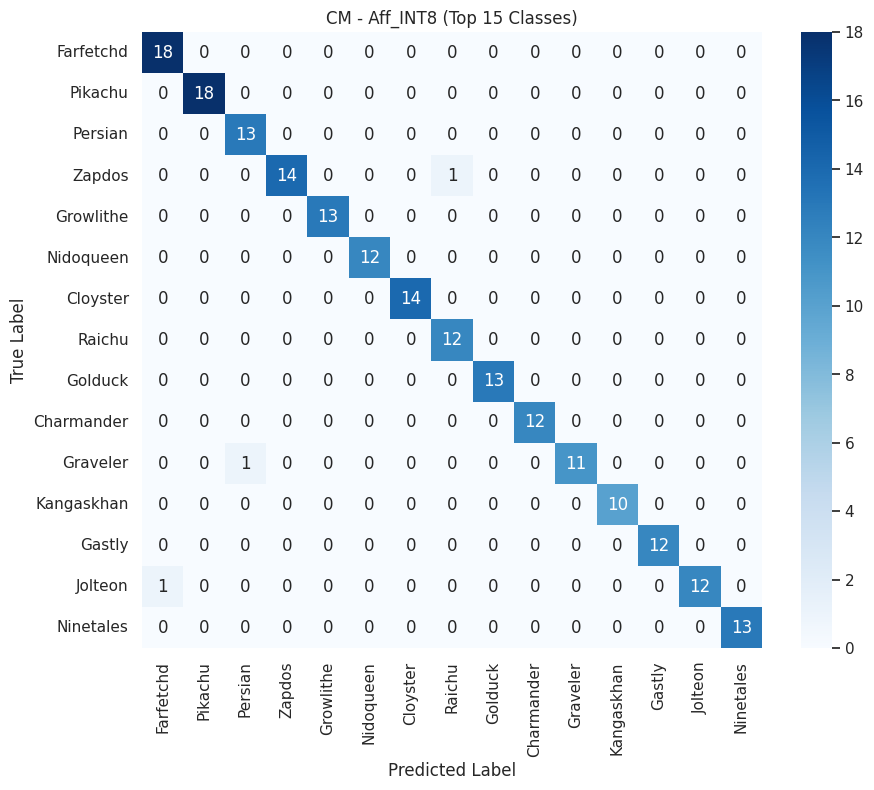

In [ ]:
# Config ableiten (Automatisch aus dem Namen)

q_name = CONFIG['quant_model_name']
q_method = 'affine' if 'Aff' in q_name else 'symmetric'
if 'Po2' in q_name: q_method = 'power2'
q_bits = 4 if 'INT4' in q_name else 8

# Custome quantized affine int8 
q_path = os.path.join(QUANTIZED_MODELS, f"model_{q_name}.pt")
quantized_model_affine = load_model(
    CNN,
    num_classes,
    q_path,
    quant_config={'method': q_method, 'bits': q_bits}
)


print("\n=== Experiment 5: Custome Affine Simulation ===")
model_for_custome_affine = copy.deepcopy(quantized_model_affine)

fps_custome_affine, lat_custome_affine = measure_inference_time(model_for_custome_affine, test_loader, device='cpu')
print(f"Int8:  {fps_custome_affine:.2f} Bilder/sek | Latenz: {lat_custome_affine:.2f} ms")
res_custome_affine = get_all_predictions(model_for_custome_affine, test_loader, device='cpu')
print_metrics(res_custome_affine, "Custome Affine Int8")

speedup_custome = fps_custome_affine / fps_base
print(f"\n-> Beschleunigung: {speedup_custome:.2f}x schneller als Base")


plot_confusion_matrix(res_custome_affine['targets'], res_custome_affine['preds'], class_names, title=f"CM - {q_name}") 

In [ ]:
print("\n=== Experiment 6: Custome Affine Storage Quantization + FX Graph ===")

model_quantized_graph_affine= copy.deepcopy(quantized_model_affine)

quantized_model_graph_affine = Quantization.apply_fx_quantization(quantized_model_affine, train_loader,method="affine", num_batches=30)

fps_graph_affine, lat_graph_affine = measure_inference_time(quantized_model_graph_affine, test_loader, device='cpu')
print(f"Int8:  {fps_graph_affine:.2f} Bilder/sek | Latenz: {lat_graph_affine:.2f} ms")
res_graph_affine = get_all_predictions(quantized_model_graph_affine, test_loader, device='cpu')
print_metrics(res_graph_affine, "Custome Affine Int8")

speedup_quant_fx = fps_graph_affine / fps_base
print(f"\n-> Beschleunigung: {speedup8:.2f}x schneller als Base")


plot_confusion_matrix(res_graph_affine['targets'], res_graph_affine['preds'], class_names, title=f"CM - {q_name}") 


In [ ]:

speedupfpx = fps_graph_affine / fps_fx
print(f"\n-> Beschleunigung: {speedupfpx:.2f}x schneller als FX-Graph-Basemodel")